The [TensorFlow Embedding Projector](https://projector.tensorflow.org/) places
high-dimensional word vectors in a three-dimensional map where distance approximates
semantic similarity, and lets you pick a word to see its nearest neighbors. In this
assignment you build the same thing in PyTorch: you train word embeddings with
`torch.nn.Embedding`, project them to three dimensions, draw an interactive scatter, and
query the neighborhood of any token.

You will complete the parts marked with `TODO(you)`. Each raises `NotImplementedError`
until you implement it.

In [1]:
import re
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

## Corpus and vocabulary

Word embeddings are learned from co-occurrence in text. Load a compact corpus, keep the
most frequent words as the vocabulary, and turn the text into a stream of integer ids.

In [2]:
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
text = " ".join(raw["text"]).lower()
tokens = re.findall(r"[a-z]+", text)[:300_000]
counts = Counter(tokens)

V = 8000
vocab = [word for word, _ in counts.most_common(V)]
word_to_index = {word: index for index, word in enumerate(vocab)}
index_to_word = {index: word for word, index in word_to_index.items()}
corpus = [word_to_index[token] for token in tokens if token in word_to_index]

## Word2vec embeddings with softmax and cross-entropy

A word2vec model learns word embeddings by predicting context words. This is the skip-gram
architecture of word2vec: the center word predicts its context. The center word's embedding is
scored against every word in the vocabulary, a softmax turns those scores into a probability
distribution over possible context words, and the cross-entropy loss pushes up the probability
of the true context word:

$$p(o \mid c) = \frac{\exp(\mathbf{c}\cdot\mathbf{v}_o)}{\sum_{w}\exp(\mathbf{c}\cdot\mathbf{v}_w)},
\qquad L = -\log p(o \mid c).$$

The learned center embedding table is the word-vector matrix you will project.

In [3]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.center = nn.Embedding(vocab_size, dim)   # word vectors
        self.output = nn.Linear(dim, vocab_size)      # score every word as a possible context
        nn.init.uniform_(self.center.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, center_ids):
        return self.output(self.center(center_ids))

In [4]:
# Build (center, context) pairs from a sliding window
window = 3
pairs = []
for i, wc in enumerate(corpus):
    for j in range(max(0, i - window), min(len(corpus), i + window + 1)):
        if j != i:
            pairs.append((wc, corpus[j]))
pairs = np.array(pairs, dtype=np.int64)

dim, B, epochs = 64, 1024, 3
model = Word2Vec(V, dim)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

# TODO(you): write the training loop. For each mini-batch, get the (B, V) logits from the center
# ids with model(...), compute the cross-entropy loss against the true context ids with loss_fn,
# backprop, and step the optimizer. Track the per-epoch loss. After training, set
# `emb = model.center.weight.detach().cpu().numpy()`.

epoch_losses = []

for epoch in range(epochs):
    perm = np.random.permutation(len(pairs))
    pairs_shuffled = pairs[perm]

    total_loss = 0.0
    n_batches = 0

    for start in range(0, len(pairs_shuffled), B):
        batch = pairs_shuffled[start:start + B]

        center_ids = torch.tensor(batch[:, 0], dtype = torch.long)
        context_ids = torch.tensor(batch[:, 1], dtype = torch.long)
        logits = model(center_ids) 
        loss = loss_fn(logits, context_ids)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
        n_batches += 1

    epoch_loss = total_loss / n_batches
    epoch_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{epochs}  Loss: {epoch_loss:.4f}")
emb = model.center.weight.detach().cpu().numpy()

Epoch 1/3  Loss: 6.9859
Epoch 2/3  Loss: 6.7126
Epoch 3/3  Loss: 6.5748


## Projecting the embeddings to three dimensions

The embedding matrix lives in $d=64$ dimensions. To see it, project a few thousand of the most
frequent words down to three dimensions. Principal component analysis is linear and fast; UMAP is
nonlinear and tends to separate clusters more sharply. The interactive scatter lets you rotate the
cloud and hover to read each word.

In [5]:
from sklearn.decomposition import PCA

N = 1500
plot_words = vocab[:N]
X = emb[:N]

# TODO(you): compute `pca3` (N x 3) with PCA, and `umap3` with UMAP (guard UMAP in a
# try/except so a missing umap-learn does not crash the notebook).
pca3 = PCA(n_components = 3, random_state = 0).fit_transform(X)
try:
    import umap

    umap3 = umap.UMAP(
        n_components = 3,
        random_state = 0
    ).fit_transform(X)

except ImportError:
    print("umap-learn not installed.")
    umap3 = None

umap-learn not installed.


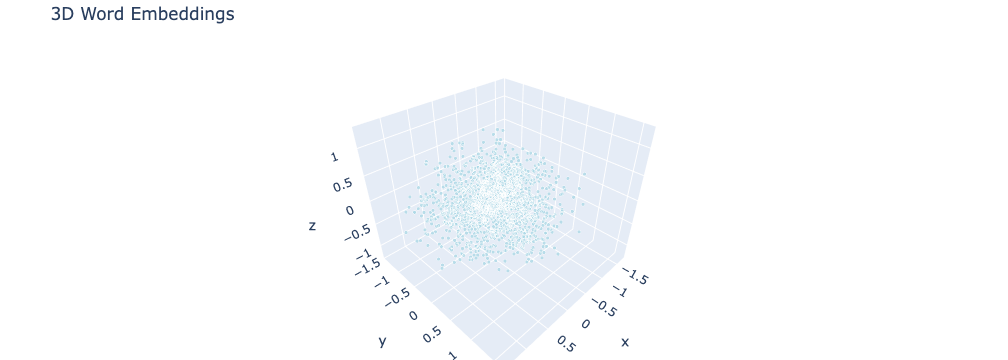

In [6]:
import plotly.graph_objects as go

# TODO(you): write `plot_embeddings(coords, words, query=None, neighbor_set=None)` that
# draws a plotly Scatter3d: hover text = the word; color/size the `query` and any words in
# `neighbor_set` distinctly. Return the figure (end the cell with the figure object).

def plot_embeddings(coords, words, query = None, neighbor_set = None):
    if neighbor_set is None:
        neighbor_set = set()

    colors = []
    sizes = []

    for w in words:
        if w == query:
            colors.append("red")
            sizes.append(10)
        elif w in neighbor_set:
            colors.append("orange")
            sizes.append(7)
        else:
            colors.append("lightblue")
            sizes.append(4)

    fig = go.Figure(
        data =[
            go.Scatter3d(
                x = coords[:, 0],
                y = coords[:, 1],
                z = coords[:, 2],
                mode = "markers",
                text = words,
                hovertemplate ="%{text}<extra></extra>",
                marker = dict(
                    color = colors,
                    size = sizes,
                    opacity = 0.8,
                ),
            )
        ]
    )

    fig.update_layout(
        title = "3D Word Embeddings",
        margin = dict(l = 0, r = 0, b = 0, t = 40),
    )

    return fig


fig = plot_embeddings(pca3, plot_words)
fig

## Querying a token's neighborhood

The projector's key feature is the neighborhood query: pick a word and see its closest
words. Closeness is measured by cosine similarity in the full embedding space (not in the
3D projection). The query below returns the top-k neighbors and highlights them in the
scatter.

In [7]:
def neighbors(word, k=10):
    # TODO(you): return the k nearest words to `word` by cosine similarity over `emb`,
    # as a list of (word, score) sorted by descending score, excluding `word` itself.
    index = word_to_index[word]
    emb_norm = emb / np.linalg.norm(emb, axis = 1, keepdims = True)
    sims = emb_norm @ emb_norm[index]
    sims[index] = -np.inf
    topk = np.argsort(-sims)[:k]
    return [(index_to_word[i], float(sims[i])) for i in topk]

for w, s in neighbors("government", 10):
    print(f"{w:15s} {s:.3f}")

municipal       0.825
federal         0.823
troops          0.822
revolutionary   0.821
commonwealth    0.820
pakistani       0.813
subcontinent    0.811
courts          0.810
fledgling       0.808
invasion        0.804


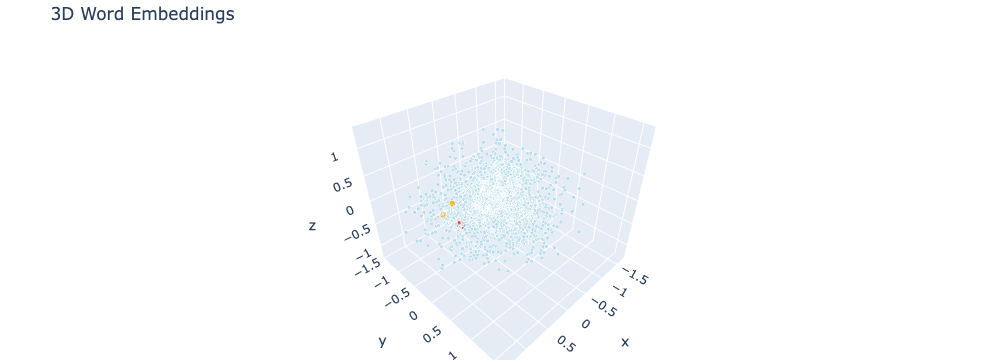

In [8]:
# TODO(you): pick a query word, get its neighbors with neighbors(query, 10), and re-draw the
# projector with plot_embeddings(...) highlighting the query and its neighbors. A word only
# appears in the plot if it is among the N most frequent words used for pca3.
query = "government"
neighbor_list = neighbors(query, 10)
neighbor_set = {w for w, _ in neighbor_list}
fig = plot_embeddings(
    pca3,
    plot_words,
    query=query,
    neighbor_set=neighbor_set
)

fig

## Exploration

Answer in the cells you add below.

1. Query several words of your choice (a few nouns, a verb, a function word). Which return clean
   semantic neighbors and which do not? Why might rare words give noisier neighbors?
2. Plot the clusters. Draw the projected embeddings (the UMAP layout separates clusters most
   clearly) and describe the groupings you see: do related words land near each other? Name a few
   clusters you can identify.